# Demand Forecasting with LightGBM

Predicting daily store sales from historical data — the kind of problem that drives
inventory and selection decisions in large-scale retail.

**Why this is built the way it is**
- It uses **lag + rolling-window features** so a tree model can learn temporal structure.
- It uses a **time-aware train/validation split** (never shuffled) and **past-only** features,
  so there is no data leakage — the single most common mistake in forecasting projects.
- It always reports performance **relative to a seasonal-naive baseline**. The headline is
  not "my RMSE is X", it is "I beat the naive forecast by Y%", which is what proves the
  model actually adds value.

> **Using real data:** the data here is generated to mirror the Kaggle *Rossmann Store Sales*
> dataset. To run on the real thing, point `DATA_PATH` at Rossmann's `train.csv` — it already
> has `Store, Date, Sales, Promo, Open` columns, so nothing else changes.

In [3]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.1f}")
RNG = np.random.default_rng(42)

OSError: dlopen(/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file)

## 1. Generate the dataset

A realistic daily sales table with store-level base demand, a long-term trend, weekly and
yearly seasonality, promotions, holidays, Sunday closures, and noise — i.e. genuine signal
for the model to recover. Replace this whole cell with `pd.read_csv("train.csv")` to use
real Rossmann data.

In [ ]:
NUM_STORES = 1000
START, END = pd.Timestamp("2022-01-01"), pd.Timestamp("2024-06-30")

HOLIDAYS = {pd.Timestamp(k): v for k, v in {
    "2022-01-01": True, "2022-12-25": True, "2022-12-26": True, "2022-11-24": False,
    "2023-01-01": True, "2023-12-25": True, "2023-12-26": True, "2023-11-23": False,
    "2024-01-01": True, "2024-05-27": False,
}.items()}

def generate():
    dates = pd.date_range(START, END, freq="D"); n = len(dates)
    stores = np.arange(1, NUM_STORES + 1)
    store_type = RNG.choice(list("abcd"), NUM_STORES, p=[.5,.2,.2,.1])
    base = RNG.lognormal(8.3, 0.45, NUM_STORES)
    slope = RNG.normal(0.00018, 0.00010, NUM_STORES)
    shut_sun = RNG.random(NUM_STORES) < 0.85

    dow, doy, idx = dates.dayofweek.to_numpy(), dates.dayofyear.to_numpy(), np.arange(n)
    wk = np.array([1.00,0.97,0.96,0.98,1.10,1.25,0.70])[dow]
    yr = 1 + 0.30*np.sin(2*np.pi*(doy-320)/365)
    is_hol = np.array([d in HOLIDAYS for d in dates])
    hol_closed = np.array([HOLIDAYS.get(d, False) for d in dates])
    pre = np.zeros(n, bool); pre[:-1] = is_hol[1:]
    hol_mult = np.where(pre, 1.20, 1.0)

    promo = RNG.random((NUM_STORES,n)) < 0.30
    promo_mult = np.where(promo, RNG.uniform(1.15,1.40,(NUM_STORES,n)), 1.0)
    noise = RNG.lognormal(0,0.10,(NUM_STORES,n))
    trend = 1 + slope[:,None]*idx[None,:]

    sales = base[:,None]*trend*wk[None,:]*yr[None,:]*hol_mult[None,:]*promo_mult*noise
    closed = ((dow==6)[None,:] & shut_sun[:,None]) | hol_closed[None,:]
    sales = np.where(closed, 0, sales); promo = np.where(closed, False, promo)
    sales = np.rint(sales).astype(int)

    return pd.DataFrame({
        "Store": np.repeat(stores, n), "Date": np.tile(dates, NUM_STORES),
        "Sales": sales.reshape(-1), "Promo": promo.reshape(-1).astype(int),
        "Open": (~closed).astype(int).reshape(-1),
        "StoreType": np.repeat(store_type, n),
        "IsHoliday": np.tile(is_hol.astype(int), NUM_STORES)})

df = generate()
print(f"{len(df):,} rows | {df.Store.nunique()} stores | "
      f"{df.Date.min().date()} -> {df.Date.max().date()}")
df.head()

912,000 rows | 1000 stores | 2022-01-01 -> 2024-06-30


,Store,Date,Sales,Promo,Open,StoreType,IsHoliday
0,1,2022-01-01,0,0,0,c,1
1,1,2022-01-02,0,0,0,c,0
2,1,2022-01-03,3627,0,1,c,0
3,1,2022-01-04,3580,0,1,c,0
4,1,2022-01-05,3470,0,1,c,0


## 2. Quick look at the data

Average sales by day of week and by month — you should see the weekend lift and the
year-end holiday peak that we baked in. This is also where SOP / interview talking points
come from.

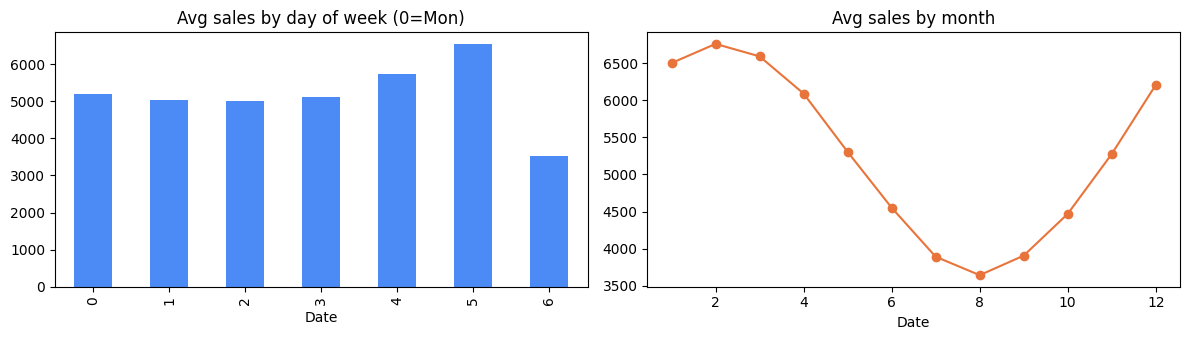

In [ ]:
open_df = df[df.Open == 1]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
open_df.groupby(open_df.Date.dt.dayofweek).Sales.mean().plot(
    kind="bar", ax=ax[0], color="#4C8BF5", title="Avg sales by day of week (0=Mon)")
open_df.groupby(open_df.Date.dt.month).Sales.mean().plot(
    marker="o", ax=ax[1], color="#E8743B", title="Avg sales by month")
plt.tight_layout(); plt.show()

## 3. Feature engineering

Two kinds of features:
- **Calendar** parts (day of week, month, week of year, weekend / month-edge flags).
- **Temporal** features — the important ones: `lag_{7,14,28}` (sales N days ago) and
  rolling mean / std over the past 7 and 30 days.

Both are computed **per store** and **shifted into the past** (`shift(1)` before rolling), so
a row never sees its own or any future value. That is what keeps the validation honest.

In [ ]:
def build_features(df):
    df = df[df.Open == 1].sort_values(["Store", "Date"]).reset_index(drop=True)
    d = df.Date.dt
    df["dayofweek"]=d.dayofweek; df["day"]=d.day; df["month"]=d.month
    df["year"]=d.year; df["weekofyear"]=d.isocalendar().week.astype(int)
    df["is_weekend"]=(df.dayofweek>=5).astype(int)
    df["is_month_start"]=d.is_month_start.astype(int)
    df["is_month_end"]=d.is_month_end.astype(int)

    g = df.groupby("Store").Sales
    for lag in (7,14,28): df[f"lag_{lag}"] = g.shift(lag)
    shifted = g.shift(1)
    for w in (7,30):
        r = shifted.groupby(df.Store).rolling(w)
        df[f"roll_mean_{w}"] = r.mean().reset_index(level=0, drop=True)
        df[f"roll_std_{w}"]  = r.std().reset_index(level=0, drop=True)

    df["StoreType"] = df.StoreType.astype("category").cat.codes
    return df.dropna().reset_index(drop=True)

data = build_features(df)
print(f"{len(data):,} rows after feature build")
data.head()

765,608 rows after feature build


,Store,Date,Sales,Promo,Open,StoreType,IsHoliday,dayofweek,day,month,...,is_weekend,is_month_start,is_month_end,lag_7,lag_14,lag_28,roll_mean_7,roll_std_7,roll_mean_30,roll_std_30
0,1,2022-02-07,4079,0,1,2,0,0,7,2,...,0,0,0,"4,751.0","3,916.0","3,470.0","4,521.1",879.2,"4,219.4",751.0
1,1,2022-02-08,5068,1,1,2,0,1,8,2,...,0,0,0,"3,825.0","5,367.0","3,193.0","4,425.1",886.6,"4,234.4",743.2
2,1,2022-02-09,4716,1,1,2,0,2,9,2,...,0,0,0,"5,597.0","4,044.0","4,359.0","4,602.7",870.7,"4,284.0",747.7
3,1,2022-02-10,4050,0,1,2,0,3,10,2,...,0,0,0,"3,182.0","3,854.0","5,639.0","4,476.9",759.6,"4,325.6",735.4
4,1,2022-02-11,3927,0,1,2,0,4,11,2,...,0,0,0,"4,242.0","3,703.0","4,076.0","4,600.9",556.7,"4,354.1",706.0


## 4. Time-aware split

Hold out the **most recent 6 weeks** for validation and train on everything before. We never
shuffle — that would let the model peek at the future.

In [ ]:
VALID_WEEKS = 6
cutoff = data.Date.max() - pd.Timedelta(weeks=VALID_WEEKS)
train = data[data.Date <= cutoff]
valid = data[data.Date >  cutoff]
print(f"cutoff {cutoff.date()} | train {len(train):,} | valid {len(valid):,}")

FEATURES = ["Promo","IsHoliday","StoreType","dayofweek","day","month","year",
            "weekofyear","is_weekend","is_month_start","is_month_end",
            "lag_7","lag_14","lag_28","roll_mean_7","roll_std_7",
            "roll_mean_30","roll_std_30"]
Xtr, ytr = train[FEATURES], train.Sales.to_numpy()
Xva, yva = valid[FEATURES], valid.Sales.to_numpy()

cutoff 2024-05-19 | train 728,696 | valid 36,912


## 5. Baseline + model

**Baseline:** seasonal-naive — predict the same weekday last week (`lag_7`). Any real model
has to beat this to be worth anything.

**Model:** LightGBM regressor with early stopping on the validation set.

In [ ]:
def rmse(y,p): return float(np.sqrt(np.mean((y-p)**2)))
def mae(y,p):  return float(np.mean(np.abs(y-p)))
def mape(y,p):
    m = y > 0; return float(np.mean(np.abs((y[m]-p[m])/y[m]))*100)

base_pred = valid.lag_7.to_numpy()

model = lgb.LGBMRegressor(objective="regression", n_estimators=1200,
    learning_rate=0.05, num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=50, random_state=42, n_jobs=-1)
model.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="rmse",
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
model_pred = np.clip(model.predict(Xva, num_iteration=model.best_iteration_), 0, None)
print("best iteration:", model.best_iteration_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.124436 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1908
[LightGBM] [Info] Number of data points in the train set: 728696, number of used features: 18
[LightGBM] [Info] Start training from score 5380.938880


best iteration: 749


## 6. Results — always vs. the baseline

In [ ]:
res = pd.DataFrame([
    {"model":"Seasonal-naive baseline","RMSE":rmse(yva,base_pred),
     "MAE":mae(yva,base_pred),"MAPE":mape(yva,base_pred)},
    {"model":"LightGBM","RMSE":rmse(yva,model_pred),
     "MAE":mae(yva,model_pred),"MAPE":mape(yva,model_pred)}])
b, m = res.iloc[0], res.iloc[1]
print(res.to_string(index=False))
print(f"\nRMSE {(1-m.RMSE/b.RMSE)*100:.1f}% lower | "
      f"MAE {(1-m.MAE/b.MAE)*100:.1f}% lower | "
      f"MAPE {m.MAPE:.1f}% vs {b.MAPE:.1f}%")

                  model    RMSE     MAE  MAPE
Seasonal-naive baseline 1,444.0 1,004.5  20.6
               LightGBM   627.5   444.1   9.0

RMSE 56.5% lower | MAE 55.8% lower | MAPE 9.0% vs 20.6%


## 7. What the model learned

Feature importance tells the story: recent-sales rolling means and lags should dominate,
which is exactly what you'd expect and what you can talk about confidently.

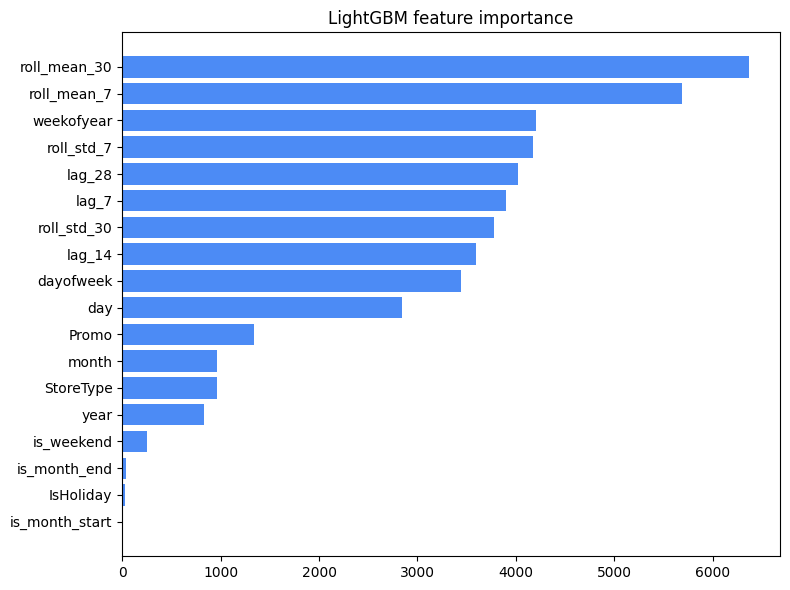

Top 5 drivers: roll_mean_30, roll_mean_7, weekofyear, roll_std_7, lag_28


In [ ]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
plt.figure(figsize=(8,6))
plt.barh(imp.index, imp.values, color="#4C8BF5")
plt.title("LightGBM feature importance"); plt.tight_layout(); plt.show()
print("Top 5 drivers:", ", ".join(imp.sort_values(ascending=False).index[:5]))

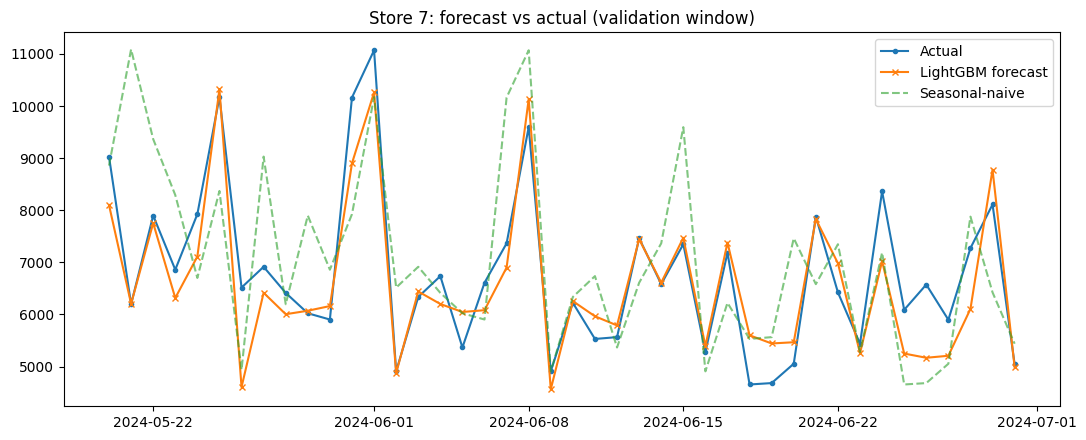

In [ ]:
sid = valid.Store.value_counts().index[0]
sv = valid[valid.Store == sid].sort_values("Date")
svp = np.clip(model.predict(sv[FEATURES], num_iteration=model.best_iteration_), 0, None)
plt.figure(figsize=(11,4.5))
plt.plot(sv.Date, sv.Sales, marker="o", ms=3, label="Actual")
plt.plot(sv.Date, svp, marker="x", ms=4, label="LightGBM forecast")
plt.plot(sv.Date, sv.lag_7, ls="--", alpha=.6, label="Seasonal-naive")
plt.title(f"Store {sid}: forecast vs actual (validation window)")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Notes & next steps

- **No leakage:** features are past-only and the split is by time — the validation score is
  a fair estimate of forecasting the genuine future.
- **Beating the baseline is the point.** Report the % improvement, not just the raw error.
- **Where to take it further:** add store-level promos-this-week counts, encode school/state
  holidays, try a per-store global model vs. clustered models, or compare against an LSTM to
  show you know when deep learning does / doesn't help on tabular data.